# Importar librerias

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import math

In [3]:
games = pd.read_csv('../data/games.csv')
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


In [5]:
games.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

Se puede obserbar que hay valores nulos en algunas de las columnas por ejemplo, parecen que hay dos juegos o es el mismo que se desconoce el nombre. 

En los años de lanzamiento puede ser que no se hizo registro completo por título de juego y el año si aparece en una fila con el mismo título, se puede recuperar ese dato copiando el año de la fila que si lo tiene. 

En genero es dato de tipo string, los valores que son nulos se cambiaría por 'Unknown', igual que nombre y rating
Para critic_score  y user_score lo mas probable es que al extraer la base de datos no se realizó el corte de puntajes en esa plataforma.

En user_score hay valores con la leyenda 'tbd', y es puede reafirmar que al momento de la extracción de los datos aun no estaba determinada el puntaje que lledaban los usuarios al título.  

# Preparar los datos

In [6]:
#Reemplaza los nombres de las columnas (ponlos en minúsculas).
games.columns = [col.lower() for col in games.columns]
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')

In [7]:
games['name'] = games['name'].astype('string')
games['platform'] = games['platform'].astype('string')
games['genre'] = games['genre'].astype('string')

In [8]:
print(games[games['name'].isna()]) 

       name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    <NA>      GEN           1993.0  <NA>      1.78      0.53      0.00   
14244  <NA>      GEN           1993.0  <NA>      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Hay dos juegos desconocidos, sin genero, ni critic_score, ni user_score, ni rating. Lo mas fácil seria optar por borrarlo pero sin embargo reportan ventas. 

In [9]:
games['name'] = games['name'].fillna('Unknown')
games['genre'] = games['genre'].fillna('Unknown')
games['rating'] = games['rating'].fillna('Unknown').astype('string')

Los valores name, genre y rating, son nulos por lo tanto seran desconocidos o 'Unknown'

In [10]:
#games['year_of_release']=games['year_of_release'].fillna(0).astype('Int64')
games['year_of_release'] = games.groupby('name')['year_of_release'].transform(lambda x: x.ffill())
games['critic_score']=games['critic_score'].fillna(0).astype('Int64')

Hay años de lanzamiento restantes de algunos titulos, sin embargo estos juegos son multiplataforma por lo tanto se tomará el año de la fila que si tiene el año con el mismo título de juego. 

El puntaje que da la crítica, los valores nulos seran llenados con 0 para ser de tipo entero. 

In [11]:
games['user_score'] = pd.to_numeric(games['user_score'].replace('tbd', pd.NA), errors="coerce")

Hay valores de User_score que al momento de la extracción de los datos tienen la leyenda 'tbd' esto significa que estaba por determinar, por lo tanto para este analisas estos valores seran remplazados primero por valor nulo. 

In [12]:
games['user_score']=games['user_score'].fillna(0)

Ahora los valores nulos serán llenados con 0 para tener valores númericos en la columna 

In [13]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  string 
 1   platform         16715 non-null  string 
 2   year_of_release  16526 non-null  float64
 3   genre            16715 non-null  string 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  Int64  
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  string 
dtypes: Int64(1), float64(6), string(4)
memory usage: 1.4 MB


Ahora se tiene un arreglo de datos sin valores nulos para poder ser analizados

In [14]:
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

Se forma una nueva columna de ventas totales donde se suman las ventas de las tres columnas por region. 

In [15]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  string 
 1   platform         16715 non-null  string 
 2   year_of_release  16526 non-null  float64
 3   genre            16715 non-null  string 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  Int64  
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  string 
 11  total_sales      16715 non-null  float64
dtypes: Int64(1), float64(7), string(4)
memory usage: 1.5 MB


# Analisis de datos 

### Número de juegos publicados por año 

In [16]:
games_per_year = games['year_of_release'].value_counts().sort_index()
print(games_per_year)

year_of_release
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      62
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     339
2000.0     350
2001.0     485
2002.0     837
2003.0     780
2004.0     764
2005.0     944
2006.0    1014
2007.0    1201
2008.0    1440
2009.0    1429
2010.0    1265
2011.0    1148
2012.0     655
2013.0     547
2014.0     582
2015.0     606
2016.0     502
Name: count, dtype: int64


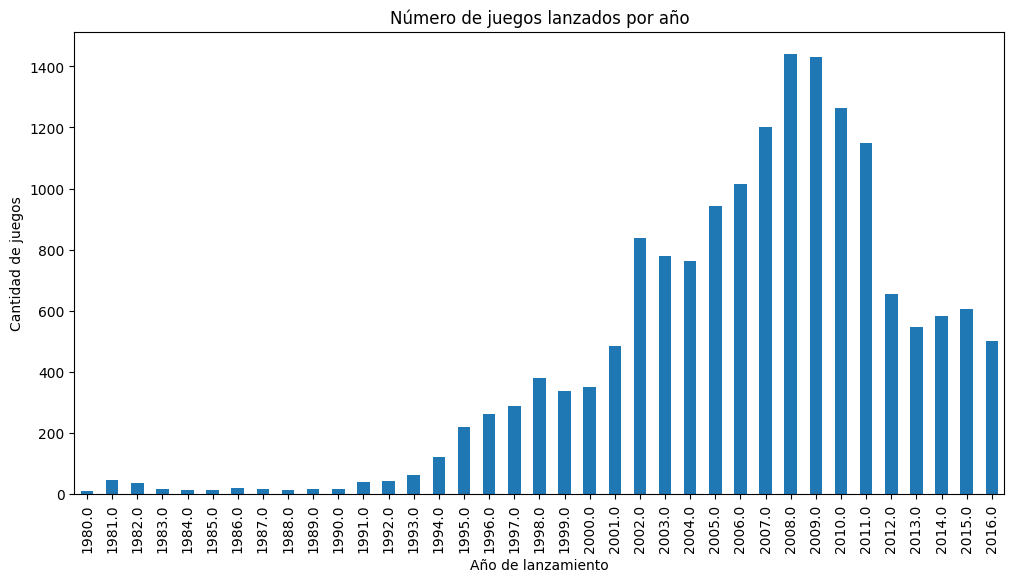

In [17]:
plt.figure(figsize=(12,6))
games_per_year.plot(kind="bar")
plt.title("Número de juegos lanzados por año")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Cantidad de juegos")
plt.show()

En esta grafica de barras se puede observar la mayor lanzamiento de juegos entre el 2008 y 2009, mas de 1400 títulos.

### Ventas totales por plataforma 

In [18]:
# Agrupar por plataforma
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales.head(10))

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


Se puede optar por las 5 plataformas con mayores ventas totales, que son PS2, X360, PS3, Wii, DS. 

In [19]:
# Seleccionar el top 5 de plataformas 
top5_platforms = platform_sales.head(5).index
# Agrupar por año y plataforma
games_top5 = games[games['platform'].isin(top5_platforms)]
life_span = games_top5.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index()
life_span['lifespan_years'] = life_span['max'] - life_span['min']
life_span['total_sales'] = games_top5.groupby('platform')['total_sales'].sum().values

life_span = life_span.sort_values(by='total_sales', ascending=False)

print(life_span)

sales_year_platform = games_top5.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
pivot_sales = sales_year_platform.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0)


  platform     min     max  lifespan_years  total_sales
1      PS2  2000.0  2011.0            11.0      1255.77
4     X360  2005.0  2016.0            11.0       971.42
2      PS3  2006.0  2016.0            10.0       939.65
3      Wii  2006.0  2016.0            10.0       907.51
0       DS  1985.0  2013.0            28.0       806.12


Para las plataformas con mayores ventas, la mediana de tiempo de vida de las plataforma es de 11 años. 

Se filtran los datos, de acuerdo a los años. Se decide filtrar los datos del top 5 de las plataformas desde el año 2000. 

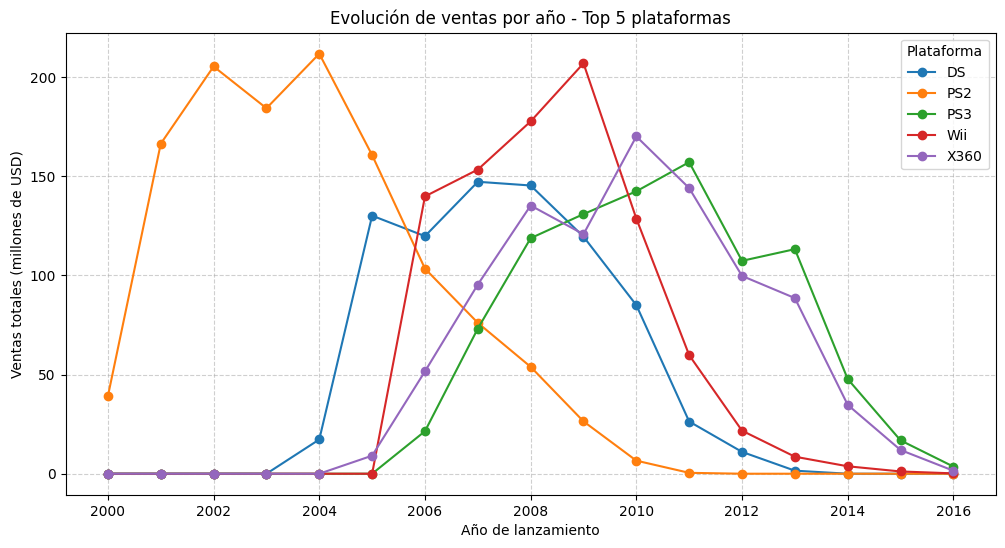

In [20]:

platform_2000=games_top5[games_top5['year_of_release']>=2000] # Filtrado de datos del 2000 al 2016
sales_year_platform = platform_2000.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
pivot_sales = sales_year_platform.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0)

plt.figure(figsize=(12,6))
for platform in pivot_sales.columns:
    plt.plot(pivot_sales.index, pivot_sales[platform], marker="o", label=platform)

plt.title("Evolución de ventas por año - Top 5 plataformas")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas totales (millones de USD)")
plt.legend(title="Plataforma")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

En esta gráfica se puede observar el comportamiento de las ventas por año del top 5 de plataformas. 

Se puede observar la interacción de las plataformas de Sony, PS2 y PS3, en el 2007 tienen casi las mismas ventas sin embargo PS2 en tendencia de menos ventas desde el año 2005 por su competencia de Nintendo la plataforma DS. Sony responde el lanzamiento de la PS3, teniendo la venta de juegos para esta plaforma en el 2006, sin embargo en este mismo año las plataformas de Nintendo DS y Wii reportaron mas ventas. La plataforma de Microsoft, la X360, tiene mejor resultados en ventas que la PS3. 

Para el año 2011, la PS2 no reporta ventas, y su remplazo la PS3 esta consolidada y las plataformas de Nintendo en franco declibe. Los lideres del mercado en ese año son la PS3 y la X360. 

/tmp/ipykernel_35378/2430659481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


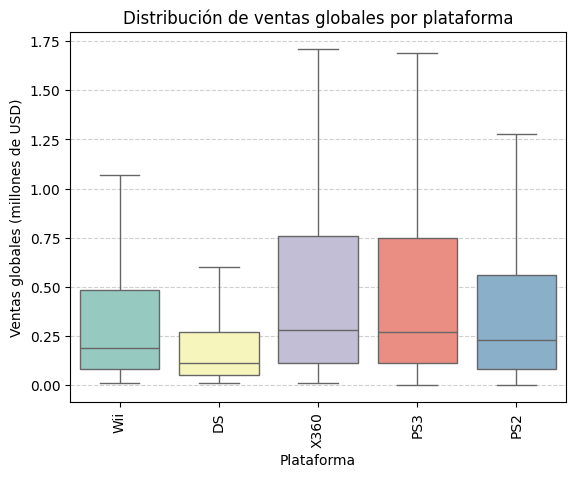

In [21]:
import seaborn as sns

# --- Crear boxplot ---
sns.boxplot(
    data=games_top5,
    x='platform',
    y='total_sales',
    showfliers=False,   
    palette="Set3"
)

plt.xticks(rotation=90)
plt.title("Distribución de ventas globales por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales (millones de USD)")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


Aqui se puede interpretar que las plataformas X360 y PS3, tienen el mismo comportamiento en ventas. Ambas plataformas PS3 y X360, comparten el mercado teniendo ventas globales en promedio de mas de 0.25 millones de dolares. 

La mediana de las cinco plataformas estan cargadas a los valores minimos, por lo tanto presentan un sesgo. 

Las plataformas X360 y PS3 tiene casi la misma variabilidad. 


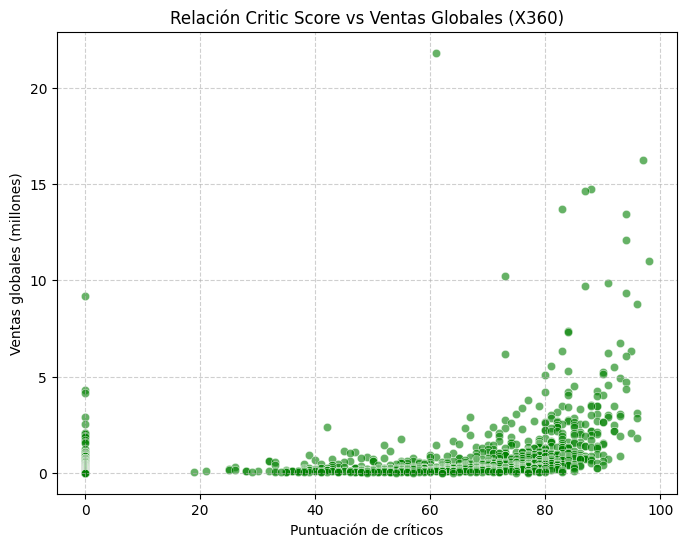

In [22]:
plataforma = 'X360'
games_reviews = games_top5.dropna(subset=['critic_score', 'user_score', 'total_sales'])
games_reviews = games_reviews[games_reviews['platform']==plataforma] 

plt.figure(figsize=(8,6))
sns.scatterplot(data=games_reviews, x='critic_score', y='total_sales', alpha=0.6, color="green")
#sns.regplot(data=games_reviews, x='critic_score', y='total_sales', scatter=False, color="black")  # línea tendencia
plt.title(f"Relación Critic Score vs Ventas Globales ({plataforma})")
plt.xlabel("Puntuación de críticos")
plt.ylabel("Ventas globales (millones)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Tomando como ejemplo la plataforma X360.

Se puede ver que si hay cierta relación de las ventas con la puntuación que les da la cítica. Mejor puntaje de la crítica mayores ventas globales.  

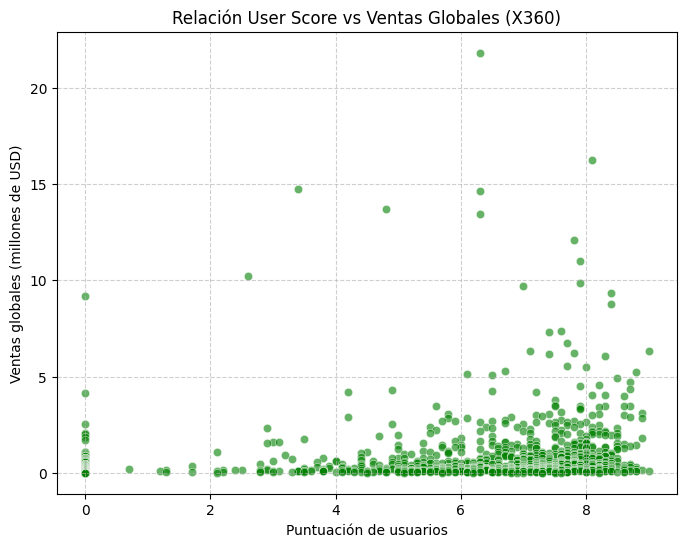

In [23]:

plt.figure(figsize=(8,6))
sns.scatterplot(data=games_reviews, x='user_score', y='total_sales', alpha=0.6, color="green")
#sns.regplot(data=games_reviews, x='user_score', y='total_sales', scatter=False, color="black")  # línea tendencia
plt.title(f"Relación User Score vs Ventas Globales ({plataforma})")
plt.xlabel("Puntuación de usuarios")
plt.ylabel("Ventas globales (millones de USD)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Utilizando de ejemplo  la plataforma X360

Parece que si hay cierta relación entre la puntuación de los usarios con las ventas globales, sin embargo hay títulos que no tienen buena calificación de los usuarios pero tienen buenas ventas globales. 

Tomando en cuenta este fenómeno puede ser que los jugadores en cierta manera confían en la punticación de las criticas para comprar algún juego, sin embargo puede pasar que los jugadores despues de jugar el título, no les gustó mucho y es la calificación que dan al juego después de su compra. 

La puntuación de la critica muchas veces la colocan equipos de Testers que les dan una versión Beta del juego, sin embargo al lazar el titulo al mercado puede que hisieron cambios finales que al final al usuario final no fueron de su agrado. 

### Identificar títulos multiplataforma 

In [24]:
# Contar en cuántas plataformas aparece cada juego
multi_platform = games.groupby('name')['platform'].nunique()
# Filtrar solo los que salieron en más de 1 plataforma
multi_platform_games = multi_platform[multi_platform > 1].index
print("Ejemplo de juegos multiplataforma:", multi_platform_games[:10])

Ejemplo de juegos multiplataforma: Index([' Frozen: Olaf's Quest', '007: Quantum of Solace',
       '007: The World is not Enough', '11eyes: CrossOver',
       '18 Wheeler: American Pro Trucker', '187: Ride or Die',
       '2 in 1 Combo Pack: Sonic Heroes / Super Monkey Ball Deluxe',
       '2002 FIFA World Cup', '2010 FIFA World Cup South Africa',
       '2014 FIFA World Cup Brazil'],
      dtype='string', name='name')


In [25]:
# Agrupar por juego y plataforma
ventas_por_plat = games[games['name'].isin(multi_platform_games)].groupby(['name','platform'])['total_sales'].sum().reset_index()

# Pivot para ver comparación lado a lado
tabla_comparacion = ventas_por_plat.pivot(index='name', columns='platform', values='total_sales').fillna(0)

print(tabla_comparacion.head(10))

platform                                            2600   3DS   DC    DS  \
name                                                                        
 Frozen: Olaf's Quest                                0.0  0.59  0.0  0.51   
007: Quantum of Solace                               0.0  0.00  0.0  0.13   
007: The World is not Enough                         0.0  0.00  0.0  0.00   
11eyes: CrossOver                                    0.0  0.00  0.0  0.00   
18 Wheeler: American Pro Trucker                     0.0  0.00  0.0  0.00   
187: Ride or Die                                     0.0  0.00  0.0  0.00   
2 in 1 Combo Pack: Sonic Heroes / Super Monkey ...   0.0  0.00  0.0  0.00   
2002 FIFA World Cup                                  0.0  0.00  0.0  0.00   
2010 FIFA World Cup South Africa                     0.0  0.00  0.0  0.00   
2014 FIFA World Cup Brazil                           0.0  0.00  0.0  0.00   

platform                                             GB  GBA    GC  GEN   N

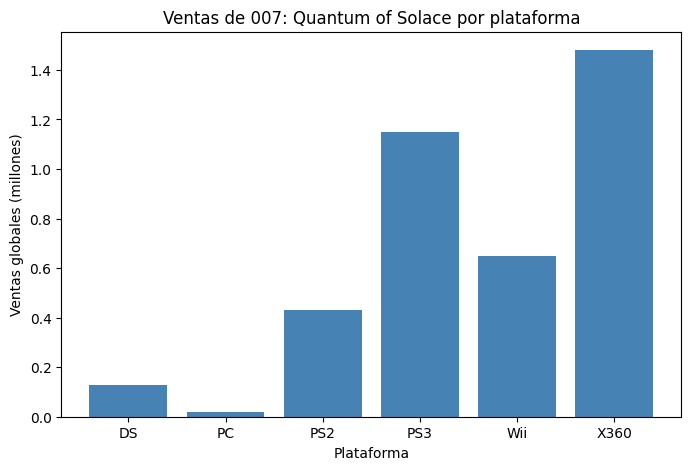

In [26]:
juego = "007: Quantum of Solace"
ventas_juego = games[games['name'] == juego].groupby('platform')['total_sales'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(ventas_juego['platform'], ventas_juego['total_sales'], color="steelblue")
plt.title(f"Ventas de {juego} por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales (millones)")
plt.show()

### Distribución general de los juegos por género

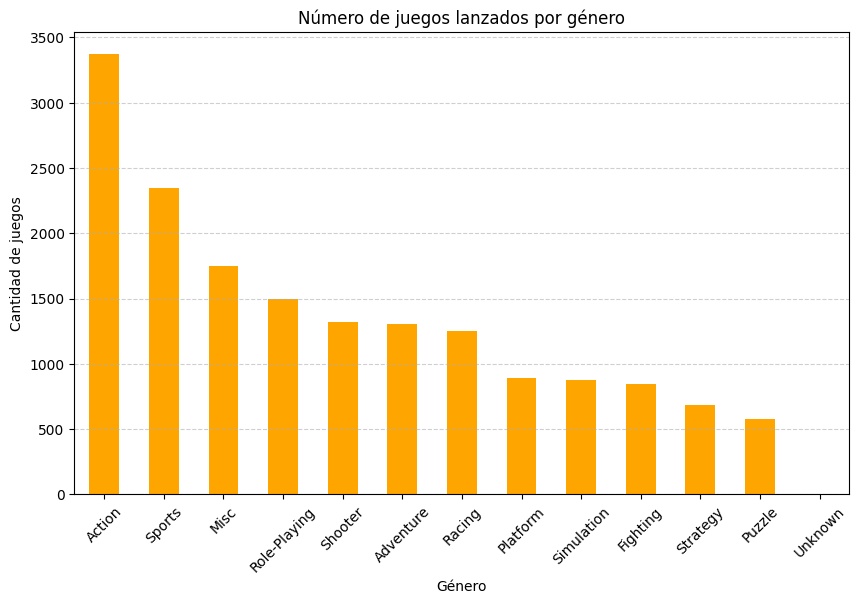

In [27]:
# Contar número de juegos por género
games_by_genre = games['genre'].value_counts()

plt.figure(figsize=(10,6))
games_by_genre.plot(kind="bar", color="orange")
plt.title("Número de juegos lanzados por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

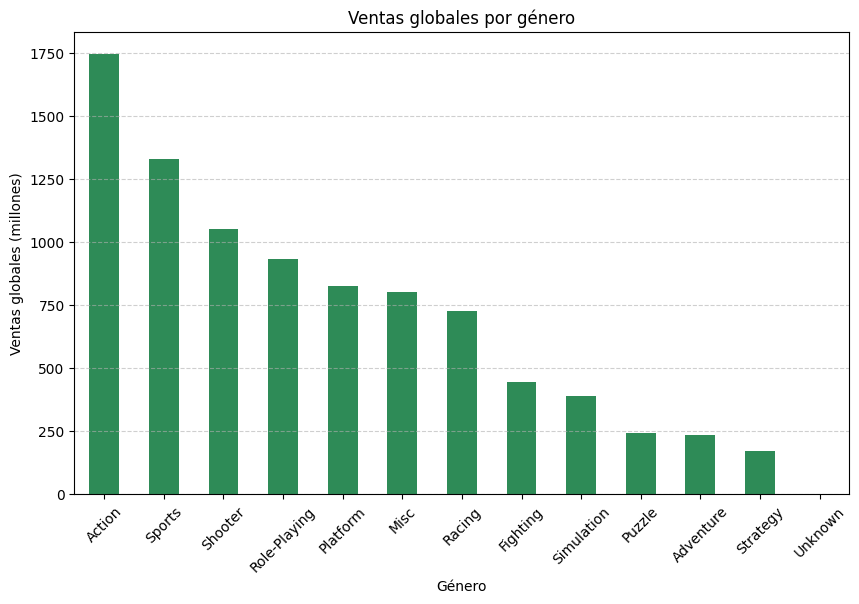

In [28]:
# Sumar ventas globales por género
sales_by_genre = games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sales_by_genre.plot(kind="bar", color="seagreen")
plt.title("Ventas globales por género")
plt.xlabel("Género")
plt.ylabel("Ventas globales (millones)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Se puede ver que el número de juegos por género si podría haber una relación en ventas. Entre mayor oferta de juegos en un género tendra mayor venta en proporcion

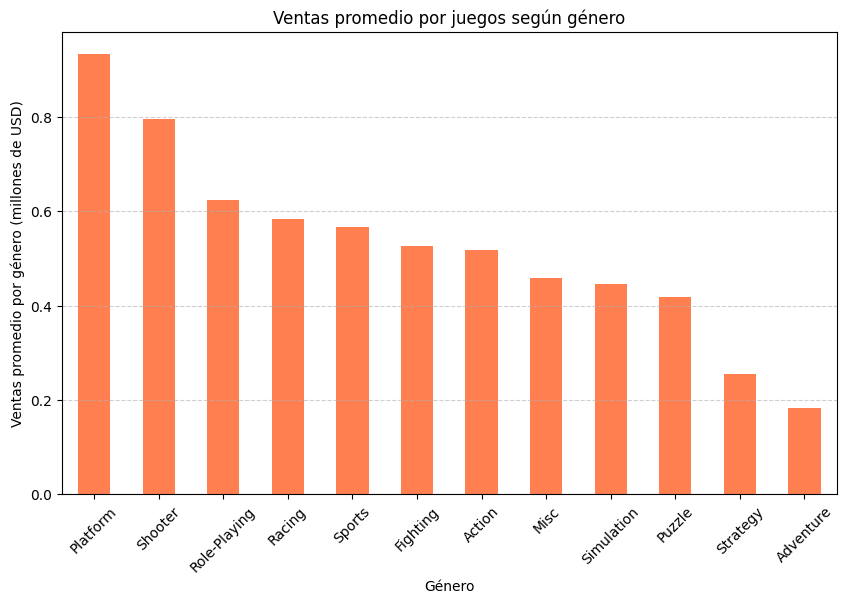

In [29]:
# Ventas promedio = ventas totales / número de juegos
games_filtro = games[games['genre'] != 'Unknown'] #Se elimina el genero desconocido 
avg_sales_by_genre = (games_filtro.groupby('genre')['total_sales'].mean()
                        .sort_values(ascending=False))

plt.figure(figsize=(10,6))
avg_sales_by_genre.plot(kind="bar", color="coral")
plt.title("Ventas promedio por juegos según género")
plt.xlabel("Género")
plt.ylabel("Ventas promedio por género (millones de USD)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Sin embargo si se grafica el promedio de ventas por género, se puede observar que los juegos de Plataforma tienen mejores ventas promedio, lo por que se puede decir que este género es el mas rentable, seguido de los juegos Shooter y Role-Playing. 

Uno pensaria que entre mayor oferta de juegos en un género eso reportará mas ventas pero con esta gráfica esa idea se descarta. Esto lo deben considerar los estudios de desarrollo. 

# Perfil de usuario para cada región

In [30]:
# Top 5 plataformas en cada región
top_na = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top_eu = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_jp = games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Top 5 NA:\n", top_na)
print("\nTop 5 EU:\n", top_eu)
print("\nTop 5 JP:\n", top_jp)

Top 5 NA:
 platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 EU:
 platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 JP:
 platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


Aqui se puede observar cierta relación entre el país de origen de la plataforma y su popularidad en cada región.

La plataforma mas popular de Norte América es X360. 

En Japón es practicamente inexistente X360, el mercado asiatico se disputa entre Sony y Nintendo con sus plataformas cada una.

Sin embargo en Europa al no tener plataformas originarias y estan entre las dos regiones productoras, tienen en el top 5, las plataformas de Sony, PS2 y PS3, entrando en tercero la X360 y en cuarto esta Wii de Nintendo. 

Japón, gusta de consolas portatiles que de sobremesa  acompración de los mercados occidentales. 

In [31]:
# Top 5 géneros  en cada región
top_genre_na = games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top_genre_eu = games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_genre_jp = games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Top 5 géneros NA:\n", top_genre_na)
print("\nTop 5 géneros EU:\n", top_genre_eu)
print("\nTop 5 géneros JP:\n", top_genre_jp)

Top 5 géneros NA:
 genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 géneros EU:
 genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 géneros JP:
 genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


En el top 5 de géneros por zonas se parecen mucho los perfiles Occidentales. 

Los generos Action y Sports aparecen en el Top 3 de las tres regiones. El genero de Shooter en los perfiles occidentales en ambos aparece en tercer lugar. 

El perfil Japones, gusta mas de los Role-Playing, y no es de extrañarse ya que ahí al lanzado populares y exitosos juegos como son los de Final Fantasy. 

Los europeos tienen una diferencias con los Norte Americanos, gustan de los juegos de Racing, y los Norte americanos junto con los japoneses comparten un gusto por los juegos de Plataforma. 



In [32]:
# Ventas por rating en cada región
sales_by_rating = games.groupby('rating')[['na_sales','eu_sales','jp_sales']].sum().sort_values(by='na_sales', ascending=False)
print(sales_by_rating)

         na_sales  eu_sales  jp_sales
rating                               
E         1292.99    710.25    198.11
Unknown   1242.46    613.83    841.96
T          759.75    427.03    151.40
M          748.48    483.97     64.24
E10+       353.32    188.52     40.20
K-A          2.56      0.27      1.46
EC           1.53      0.11      0.00
AO           1.26      0.61      0.00
RP           0.00      0.08      0.00


Se puede oberbar que el Perfil Norte Americano es Quien mas consume juegos. 

En los perfiles Occidentales la clasificación E para todos, es la que reporta vas ventas, sin embargo en japón los juegos con un Rating desconocido son los mas vendidos. 

Con los rating de T adolecentes y M de maduro +17, el mercado norteamericano consume mas juegos para adolecentes, y en europa se consume mas juegos M a comparación que los T de adolecentes. 

El otro género que reporta ventas en las tres regiones es E 10+ que es para todos desde los 10 años en adelante. 

Sin embargo los géneros que no reportan grandes ventas son las de Kids - Adults en las tres zonas, sin embargo europa gustan más de los géneros para adultos. 

En Japón no les interesa los juegos de Adultos, ni de EC que son para niños de temprana edad. 

Parece que a los jugadores de las tres regiones les importa que los juegos si tengan una clasificación ya los RP son los que reportan casi nulas ventas. 

Se puede observar que los juegos que mas se venden son los que son para todos, estos juegos paracen tener mejor rentabilidad. 



In [33]:
print(games[games['rating']=='M'].head(5))

                              name platform  year_of_release    genre  \
16              Grand Theft Auto V      PS3           2013.0   Action   
17   Grand Theft Auto: San Andreas      PS2           2004.0   Action   
23              Grand Theft Auto V     X360           2013.0   Action   
24     Grand Theft Auto: Vice City      PS2           2002.0   Action   
29  Call of Duty: Modern Warfare 3     X360           2011.0  Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
16      7.02      9.09      0.98         3.96            97         8.2   
17      9.43      0.40      0.41        10.57            95         9.0   
23      9.66      5.14      0.06         1.41            97         8.1   
24      8.41      5.49      0.47         1.78            95         8.7   
29      9.04      4.24      0.13         1.32            88         3.4   

   rating  total_sales  
16      M        21.05  
17      M        20.81  
23      M        16.27  
24      M 

In [34]:
print(games[games['rating']=='Unknown'].head(10))

                             name platform  year_of_release         genre  \
1               Super Mario Bros.      NES           1985.0      Platform   
4        Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                          Tetris       GB           1989.0        Puzzle   
9                       Duck Hunt      NES           1984.0       Shooter   
10                     Nintendogs       DS           2005.0    Simulation   
12    Pokemon Gold/Pokemon Silver       GB           1999.0  Role-Playing   
18              Super Mario World     SNES           1990.0      Platform   
20  Pokemon Diamond/Pokemon Pearl       DS           2006.0  Role-Playing   
21               Super Mario Land       GB           1989.0      Platform   
22            Super Mario Bros. 3      NES           1988.0      Platform   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
1      29.08      3.58      6.81         0.77             0         0.0   
4 

# Pruebas de Hipotesis

## Primera prueba

H₀  (nula): La media de User_Score en Xbox One = la media de User_Score en PC.

H₁ (Alternativa): Las medias son diferentes.

In [35]:
# Filtrar plataformas
xbox_scores = games[games['platform'] == "XOne"]['user_score'].dropna()
pc_scores   = games[games['platform'] == "PC"]['user_score'].dropna()

t_stat, p_value = st.ttest_ind(xbox_scores, pc_scores, equal_var=False)  # Welch’s t-test

print("t =", round(t_stat,3), " p =", round(p_value,4))
print("Media Xbox One:", round(xbox_scores.mean(),2))
print("Media PC:", round(pc_scores.mean(),2))

t = -3.494  p = 0.0005
Media Xbox One: 4.81
Media PC: 5.58


In [36]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos H0: La media de User_Score en Xbox One es diferente a la media de User_Score en PC.")
else:
    print("No rechazamos H0: En promedio, las calificaciones de usuarios en Xbox One y PC son estadísticamente iguales.")

Rechazamos H0: La media de User_Score en Xbox One es diferente a la media de User_Score en PC.


## Segunda Prueba

H₀ (nula): La media de User_Score en Action = la media de User_Score en Sports.

H₁ (alternativa): Las medias son diferentes.

In [37]:
# Filtrar Action y Sports
action_scores  = games[games['genre'] == "Action"]['user_score'].dropna()
sports_scores  = games[games['genre'] == "Sports"]['user_score'].dropna()

t_stat, p_value = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print("t =", round(t_stat,3), " p =", round(p_value,4))
print("Media Action:", round(action_scores.mean(),2))
print("Media Sports:", round(sports_scores.mean(),2))

t = 5.715  p = 0.0
Media Action: 3.83
Media Sports: 3.27


In [38]:
alpha = 0.03
if p_value < alpha:
    print("Rechazamos H0:Las calificaciones promedio de usuarios en Action y Sports son diferentes, con Action ligeramente mejor valorado.")
else:
    print("No rechazamos H0: La media de User_Score en Action = la media de User_Score en Sports.")

Rechazamos H0:Las calificaciones promedio de usuarios en Action y Sports son diferentes, con Action ligeramente mejor valorado.


# Conclusión general

Se pudo observar el comportamiento de los consumidores desde lo general a lo particular. 

### Plataformas:

Las consolas de sobremesa como PS2, PS3, Xbox 360 y Wii dominaron las ventas globales entre 2000–2015.

En Japón destacan las portátiles (DS, 3DS, PSP), mientras que en Norteamérica y Europa las consolas de sobremesa tuvieron mayor peso.

El ciclo de vida de una plataforma suele durar entre 10 y 11 años, con un pico de ventas a mitad de su existencia.

### Géneros:

Shooter, Sports, Action y Role-Playing concentran la mayoría de las ventas.

Role-Playing es muy fuerte en Japón, mientras que Shooter y Sports dominan en NA y EU.

### ESRB Ratings:

En NA/EU, los juegos M (Mature) y T (Teen) tienen gran peso gracias a franquicias como Call of Duty y GTA. 

En Japón, las clasificaciones ESRB no son tan influyentes; los títulos más vendidos son RPGs y muchos no tienen calificación ESRB registrada.

### Reseñas vs Ventas:

Existe una correlación débil pero positiva entre reseñas (sobre todo críticas) y ventas.

Un buen puntaje no garantiza ventas masivas: la plataforma, la franquicia y el marketing influyen más.

### Pruebas de hipótesis:

Xbox One vs PC: no hay diferencia significativa en la calificación promedio de usuarios → los jugadores perciben la calidad similar en ambas plataformas.

Action vs Sports: sí existe diferencia significativa → los juegos de Acción tienden a recibir mejores calificaciones promedio que los de Deportes.
